In [2]:
import os #operating system

%matplotlib inline 
from matplotlib import pyplot as plt #biblioteca de plotagem do matplotlib
import numpy as np
from photutils.aperture import EllipticalAperture #pra fotometria astronomica 

In [3]:
# Use custom style for larger fonts and figures
plt.style.use('guide.mplstyle')

In [4]:
# Set up the random number generator, allowing a seed to be set from the environment
seed = os.getenv('GUIDE_RANDOM_SEED', None)

if seed is not None:
    seed = int(seed)
    
# This is the generator to use for any image component which changes in each image, e.g. read noise
# or Poisson error
noise_rng = np.random.default_rng(seed)

In [5]:
from convenience_functions import show_image

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Blank Image + Noise
  </span>
</h1>

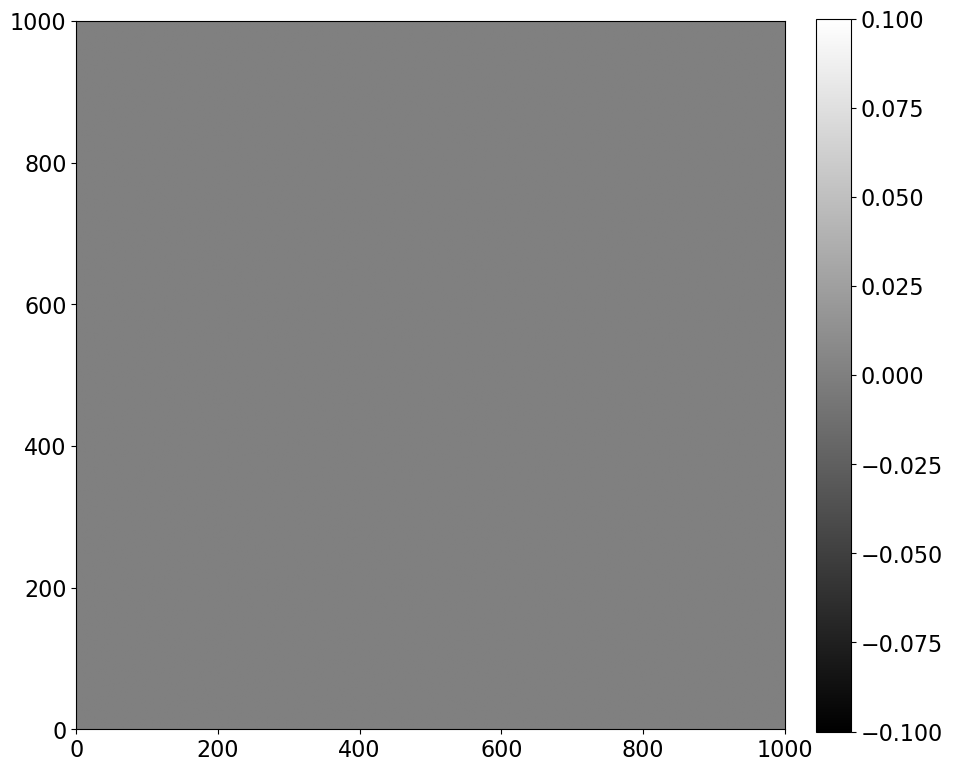

In [28]:
synthetic_image = np.zeros([1000, 1000])
show_image(synthetic_image, cmap='gray')

<Figure size 1000x1000 with 0 Axes>

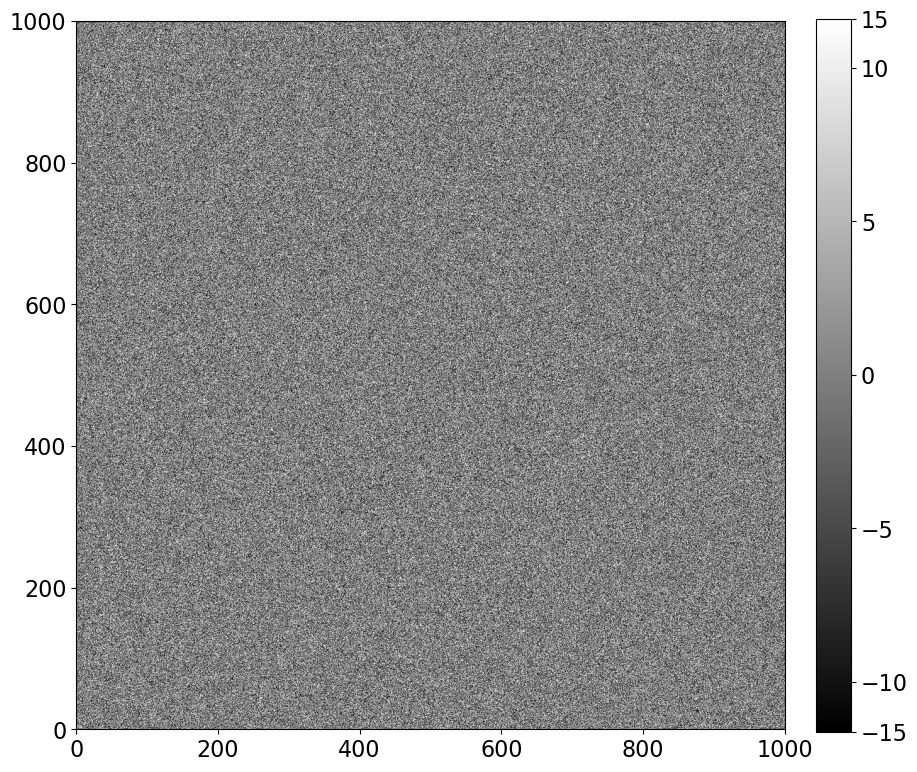

In [29]:
def read_noise(image, amount, gain=1):
                shape = image.shape
                noise = noise_rng.normal(scale=amount/gain, size=shape) 
                return noise
#image e amount são parametros de entrada, amount é a quntidade de ruído em elétrons

#noise_rng é o aleatório que colocamos lá em cima
#.normal() é a função que gera números com a distribuição normal (Gaussiana)
#scale=amount/gain é a coisa toda que ta explicada no comentário aí em cima
    #exemplo: se amount=5 e gain=1 → scale=5/1  = 5 ADU, quanto menor esse número, menor o ruído
#size=shape é que vai ficar do mesmo tamanho que a imagem de entrada

'''
gain=1 é um parametro opcional, ganho de camera

Gain é uma 'ponte' entre elétrons e ADU → GAIN = (elétrons) / (ADU) 
Quantos elétrons são necessários para aumentar 1 unidade no ADU?
exemplos:
Gain = 1 e⁻/ADU	1 elétron vira 1 ADU
Gain = 2 e⁻/ADU	Precisam 2 elétrons para 1 ADU (menos sensível)
Gain = 0.5 e⁻/ADU	1 elétron vira 2 ADU (mais sensível)
'''

plt.figure()
noise_im=synthetic_image + read_noise(synthetic_image, 5) #amount = 5, ruído de 5 elétrons
show_image(noise_im, cmap='gray')

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

**Charge-Coupled Device (CCD)**: sensor that operates like a grid of "buckets" (pixels) that collect electrons released by light.

**ADU**: Analog-to-digital unit, número que o computador armazena para cada pixel da imagem. Quando abre uma imagem FITS, cada pixel tem um valor em ADU.

Fóton atinge o CCD → Fótons viram elétrons (fotoelétrons, cada fóton pode liberar um elétron no sensor) → Elétrons viram voltagem (convertidos em tensão elétrica ao ler o CCD) → Voltagem vira um número ADU (o conversor A/D transforma a voltagem em número inteiro).

**FITS**: Flexible Image Transport System, padrão de imagens e dados astronomicos

**Read noise**: Ruído de leitura
**Bias**: Nível de referencia 

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide

https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-03-Construction-of-an-artificial-but-realistic-image.html